In [1]:
import os
import random
import math
import numpy as np
import pandas as pd
import time
import copy
import requests
import shutil
import cv2

from tqdm import tqdm
from glob import glob
from zipfile import ZipFile
from dataclasses import dataclass
from typing import List, Tuple, Union
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchinfo import summary
from torch.utils.data import DataLoader, Dataset, random_split
from torch.optim import lr_scheduler

from torchvision.models import resnet18
from torchvision import datasets, transforms as T
from torchvision.transforms import functional

from torch.utils.tensorboard import SummaryWriter
from torchmetrics import MeanMetric
from torchmetrics.classification import MulticlassAccuracy

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter)

2026-06-23 13:07:12.124408: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782220032.383352      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782220032.455696      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782220033.049899      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782220033.049958      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782220033.049963      57 computation_placer.cc:177] computation placer alr

In [2]:
bold = f"\033[1m"
reset = f"\033[0m"

In [3]:
# TO check whether all the images contain jpg format

path_img = '/kaggle/input/open-cv-py-torch-project-2-classification-round-4/images/images/*.*'
other_files = [i for i in glob(path_img) if not i.lower().endswith('.jpg')]
print(len(other_files))

0


In [4]:
# paths 
root_dir = '/kaggle/working/'
dataroot = os.path.join(root_dir, 'datasets')
train_data_path = os.path.join(root_dir, 'train.csv')
valid_data_path = os.path.join(root_dir, 'valid.csv')
test_data_path = os.path.join(root_dir, 'test.csv')
train_img_datasets = os.path.join(dataroot, 'train')
valid_img_datasets = os.path.join(dataroot, 'valid')
test_img_datasets = os.path.join(dataroot, 'test')
model_checkpoint = os.path.join(root_dir, 'model_checkpoint/ken_food_models')

In [5]:
# creating folders in the working directory
os.makedirs(train_img_datasets, exist_ok = True)
os.makedirs(valid_img_datasets, exist_ok = True)
os.makedirs(test_img_datasets, exist_ok = True)
os.makedirs(model_checkpoint, exist_ok = True)

In [6]:
# copying test.csv from input to working
shutil.copy2('/kaggle/input/open-cv-py-torch-project-2-classification-round-4/test.csv',
             test_data_path)

'/kaggle/working/test.csv'

In [7]:
# reading csv files of train.csv
df_train= pd.read_csv('/kaggle/input/open-cv-py-torch-project-2-classification-round-4/train.csv')

In [8]:
# splitting the data into train and valid
train_data,valid_data = train_test_split(df_train,
                                         test_size = 0.2,
                                         random_state  = 42)

In [9]:
# creating train and valid csv files
train_data.to_csv(train_data_path, index = False)
valid_data.to_csv(valid_data_path, index = False)

In [10]:
# function for Copying images from images folder to specified directory
def image_copy(name_path, src_path, dst_path):
    data = pd.read_csv(name_path)
    names = data.iloc[:,0].tolist()

    for i in names:
        name_jpg = str(i) + '.jpg'

        src_image = os.path.join(src_path, name_jpg)
        dst_image = os.path.join(dst_path, name_jpg)

        if os.path.exists(src_image):
            shutil.copy2(src_image, dst_image)
        else:
            print(f"Warning: {src_image} not found in {dst_image}")
            
            

In [11]:
# Copying images from images folder to specified train directory
image_copy(name_path = train_data_path,
           src_path = '/kaggle/input/open-cv-py-torch-project-2-classification-round-4/images/images',
           dst_path = train_img_datasets)

In [12]:
# Copying images from images folder to specified test directory
image_copy(name_path = test_data_path,
           src_path = '/kaggle/input/open-cv-py-torch-project-2-classification-round-4/images/images',
           dst_path = test_img_datasets)

In [13]:
# Copying images from images folder to specified test directory
image_copy(name_path = valid_data_path,
           src_path = '/kaggle/input/open-cv-py-torch-project-2-classification-round-4/images/images',
           dst_path = valid_img_datasets)

In [14]:
df = pd.read_csv(train_data_path)

In [15]:
df.head()

,id,class
0,10862709929141092447,nyamachoma
1,12253291056072394591,kachumbari
2,8833937690167916386,chapati
3,15932281450747424208,masalachips
4,8712052877055502942,chapati


## <font style="color:green">1. Data Loader [10 Points]</font>

In this section, you have to write a class or methods, which will be used to get training and validation data loader.

You need to write a custom dataset class to load data.

**Note; There is   no separate validation data. , You will thus have to create your own validation set, by dividing the train data into train and validation data. Usually, we do 80:20 ratio for train and validation, respectively.**


For example:

```python
class KenyanFood13Dataset(Dataset):
    """
    
    """
    
    def __init__(self, *args):
    ....
    ...
    
    def __getitem__(self, idx):
    ...
    ...
    

```


```python
def get_data(args1, *args):
    ....
    ....
    return train_loader, test_loader
```

In [36]:
df.columns

Index(['id', 'class'], dtype='object')

In [42]:
class Kenyanfood(Dataset):
    def __init__(self, csv_path, 
                 data_root, transform = None,
                 class_to_idx = None):
        """
        args:
        csv_path : path of csv files 'train.csv', 'valid.csv' and test.csv
        img_dir : path of images
        transform : preprocessing
        class_to_idx : text to number mapping
        
        """
        
        self.df = pd.read_csv(csv_path)
        self.data_root = data_root
        self.transform = transform

        # To check whether it is a test set
        self.is_test = 'class' not in self.df.columns
        
        # label encoding
        if not self.is_test:    
            if class_to_idx is None:
                unique_classes = sorted(self.df['class'].unique())
                self.class_to_idx = {class_name:idx for idx, class_name in enumerate(unique_classes)}
            else:
                self.class_to_idx = class_to_idx
        else:
            self.class_to_idx = None

    def __len__(self):
        """
            return length of the dataset
        """
        return len(self.df)

    def __getitem__(self, idx):
        # get the row of the data
        row = self.df.iloc[idx]
        
        # extract the image name
        img_name = str(row['id']) + '.jpg'
        img_path = os.path.join(self.data_root, img_name)

        # Read the image
        image = cv2.imread(img_path, 1)
        
        # Convert the image from bgr to rgb
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # converting to PIL image
        image = Image.fromarray(image)

        # apply transforms and return
        if self.transform:
            image = self.transform(image)

        # return only the image in case of test set
        if self.is_test:
            return image, str(row['id'])
        else:
            # convert the label into numeric
            label = row['class']
            numerical_label = self.class_to_idx[label]
            return image, torch.tensor(numerical_label)
        

In [17]:
# image preprocessing techniques
def image_preprocess_transforms(img_height, img_width):
    preprocess = T.Compose([
        T.Resize((img_height, img_width), antialias = True),
        T.ToTensor()
    ])

    return preprocess

In [43]:
def get_data(img_height, img_width, 
             batch_size, num_workers = 1):

    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    
    image_preprocess = image_preprocess_transforms(img_height, img_width)

    # Common image augumentations applied to valid and test set
    common_transforms = T.Compose([
        image_preprocess,
        T.Normalize(mean = mean, std = std)
    ])

    # preprocessing applied to train images
    train_transforms = T.Compose([
        T.GaussianBlur(kernel_size = (5,5)),
        image_preprocess,
        T.Normalize(mean = mean, std = std)
    ])

    train_dataset  = Kenyanfood(
        csv_path = train_data_path, 
        data_root = train_img_datasets, 
        transform = train_transforms,
        class_to_idx = None
    )

    valid_dataset = Kenyanfood(
        csv_path = valid_data_path, 
        data_root = valid_img_datasets, 
        transform = common_transforms,
        class_to_idx = train_dataset.class_to_idx
    )

    test_dataset = Kenyanfood(
        csv_path = test_data_path, 
        data_root = test_img_datasets, 
        transform = common_transforms,
    )

    # train dataloader
    train_loader = DataLoader(train_dataset, batch_size = batch_size,
                              shuffle = True, num_workers = num_workers)

    # valid dataloader
    valid_loader = DataLoader(valid_dataset, batch_size = batch_size,
                              shuffle = False, num_workers = num_workers)

    # test dataloader
    test_loader = DataLoader(test_dataset, batch_size = batch_size,
                              shuffle = False, num_workers = num_workers)

    return train_loader, valid_loader, test_loader

## <font style="color:green">2. Configuration [5 Points]</font>

**Define your configuration here.**

For example:


```python
@dataclass
class TrainingConfiguration:
    '''
    Describes configuration of the training process
    '''
    batch_size: int = 10 
    epochs_count: int = 50  
    init_learning_rate: float = 0.1  # initial learning rate for lr scheduler
    log_interval: int = 5  
    test_interval: int = 1  
    data_root: str = "/kaggle/input/opencv-pytorch-project-2-classification-round-3" 
    num_workers: int = 2  
    device: str = 'cuda'  
    
```

In [19]:
@dataclass(frozen=True)
class DatasetConfig:
    NUM_CLASSES: int = 13
    IMG_WIDTH:   int = 224
    IMG_HEIGHT:  int = 224
    BATCH_SIZE:      int = 32
    NUM_WORKERS:     int = 4

@dataclass(frozen=True)
class TrainingConfig:  
    EPOCHS:          int = 20
    LEARNING_RATE: float = 1e-4
    CHECKPOINT_DIR:  str = os.path.join('model_checkpoint', 'kenya_food_models')
    LOG_DIR:        str   = "kenyan_food_res18"
    TEST_INTERVAL:  int   = 1


@dataclass(frozen=True)
class InferenceConfig:
    BATCH_SIZE:  int = 32

In [20]:
def system_config(SEED_VALUE=42, package_list=None):
    """
    Configures the system environment for PyTorch-based operations.

    Args:
        SEED_VALUE (int): Seed value for random number generation. Default is 42.
        package_list (str): String containing a list of additional packages to install
        for Google Colab or Kaggle. Default is None.

    Returns:
        tuple: A tuple containing the device name as a string and a boolean indicating GPU availability.
    """

    random.seed(SEED_VALUE)
    np.random.seed(SEED_VALUE)
    torch.manual_seed(SEED_VALUE)

    def is_running_in_colab():
        return 'COLAB_GPU' in os.environ

    def is_running_in_kaggle():
        return 'KAGGLE_KERNEL_RUN_TYPE' in os.environ

    #--------------------------------
    # Check for availability of GPUs.
    #--------------------------------
    if torch.cuda.is_available():
        print('Using CUDA GPU')

        # This section for installing packages required by Colab.
        if is_running_in_colab() or is_running_in_kaggle():
            print('Installing required packages...')
            !pip install {package_list}

        # Set the device to the first CUDA device.
        DEVICE = torch.device('cuda')
        print("Device: ", DEVICE)
        GPU_AVAILABLE = True

        torch.cuda.manual_seed(SEED_VALUE)
        torch.cuda.manual_seed_all(SEED_VALUE)

        # Performance and deterministic behavior.
        torch.backends.cudnn.enabled = True       # Provides highly optimized primitives for DL operations.
        torch.backends.cudnn.deterministic = True # Insures deterministic even when above cudnn is enabled.
        torch.backends.cudnn.benchmark = False    # Setting to True can cause non-deterministic behavior.

    elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
        print('Using Apple Silicon GPU')

        # Set the device to the Apple Silicon GPU Metal Performance Shader (MPS).
        DEVICE = torch.device("mps")
        print("Device: ", DEVICE)
        # Environment variable that allows PyTorch to fall back to CPU execution
        # when encountering operations that are not currently supported by MPS.
        os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
        GPU_AVAILABLE = True

        torch.mps.manual_seed(SEED_VALUE)
        torch.use_deterministic_algorithms(True)

    else:
        print('Using CPU')
        DEVICE = torch.device('cpu')
        print("Device: ", DEVICE)
        GPU_AVAILABLE = False

        if is_running_in_colab() or is_running_in_kaggle():
            print('Installing required packages...')
            !pip install {package_list}
            print('Note: Change runtime type to GPU for better performance.')

        torch.use_deterministic_algorithms(True)

    return str(DEVICE), GPU_AVAILABLE

In [21]:
DEVICE, GPU_AVAILABLE = system_config()

Using CUDA GPU
Installing required packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 62.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 33.5 MB/s eta 0:00:00
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
  Attempting uninstall: alabaster
    Found existing installation: alabaster 1.0.0
    Uninstalling alabaster-1.0.0:
      Successfully uninstalled alabaster-1.0.0
  Attempting uninstall: sphinx
    Found existing installation: Sphinx 8.2.3
    Uninstalling Sphinx-8.2.3:
      Successfully uninstalled Sphinx-8.2.3
Device:  cuda


In [44]:
train_loader, valid_loader, test_loader = get_data(DatasetConfig.IMG_WIDTH, 
                                                   DatasetConfig.IMG_HEIGHT,
                                                   DatasetConfig.BATCH_SIZE, 
                                                   DatasetConfig.NUM_WORKERS)

## <font style="color:green">3. Evaluation Metric [10 Points]</font>

**Define methods or classes that will be used in model evaluation. For example, accuracy, f1-score etc.**

## <font style="color:green">4. Train and Validation [5 Points]</font>


**Write the methods or classes to be used for training and validation.**

In [23]:
def train(
    DEVICE, 
    train_config: TrainingConfig,
    dataset_config: DatasetConfig, 
    model: nn.Module,
    optimizer: torch.optim.Optimizer, 
    train_loader: torch.utils.data.DataLoader,
    epoch_idx: int,
    total_epochs: int
) -> Tuple[float, float]:

    # change model in training mode
    model.train()

    acc_metric = MulticlassAccuracy(num_classes = dataset_config.NUM_CLASSES, 
                                    average = 'micro')
    mean_metric = MeanMetric()

    status = f"Train:\t {bold}Epoch: {epoch_idx}/{total_epochs}{reset}"

    prog_bar = tqdm(train_loader, bar_format = '{l_bar}{bar:10}{r_bar}{bar:-10b}')

    prog_bar.set_description(status)

    for data, target in prog_bar:

        # send data and target to appropriate device
        data, target = data.to(DEVICE), target.to(DEVICE)

        # Reset parameters gradient to zero
        optimizer.zero_grad()

        # forward pass to the model
        output = model(data)

        # cross entropy loss
        loss = F.cross_entropy(output, target)

        # Find gradients w.r.t training parameters
        loss.backward()
        
        # update the parameters using gradients
        optimizer.step()
        
        # Batch loss
        batch_loss = mean_metric(loss.item(), weight = data.shape[0])
        
        # Get probability score using softmax
        prob = F.softmax(output, dim = 1)
        
        # Get the index of the max probability
        pred_idx = prob.detach().argmax(dim = 1)

        # Batch accuracy
        batch_acc = acc_metric(pred_idx.cpu(), target.cpu())
        
        # update progress bar description
        step_status = status + f"\tLoss:{mean_metric.compute():.4f}, Acc: {acc_metric.compute():.4f}"             
        prog_bar.set_description(step_status)

    epoch_loss = mean_metric.compute()
    epoch_acc = acc_metric.compute()

    prog_bar.close()

    return epoch_loss, epoch_acc
        

In [24]:
def validate(
    DEVICE,
    train_config: TrainingConfig,
    dataset_config: DatasetConfig,
    model: nn.Module,
    valid_loader: torch.utils.data.DataLoader,
    epoch_idx: int,
    total_epochs: int
) -> Tuple[float, float]:
    #
    model.eval()

    acc_metric = MulticlassAccuracy(num_classes=dataset_config.NUM_CLASSES, average="micro")
    mean_metric = MeanMetric()

    status = f"Valid:\t{bold}Epoch: {epoch_idx}/{total_epochs}{reset}"

    prog_bar = tqdm(valid_loader, bar_format='{l_bar}{bar:10}{r_bar}{bar:-10b}')

    prog_bar.set_description(status)

    for data, target in prog_bar:

        # Send data and target to appropriate device.
        data, target = data.to(DEVICE), target.to(DEVICE)

        # Get the model's predicted logits.
        with torch.no_grad():
            output = model(data)

        # Compute the CE-Loss.
        valid_loss = F.cross_entropy(output, target).item()

        # Convert model's logits to probability scores.
        prob = F.softmax(output, dim=1)

        # Get the class id for the maximum score.
        pred_idx = prob.detach().argmax(dim=1)

        # Batch validation loss.
        batch_loss = mean_metric(valid_loss, weight=data.shape[0])

        # Batch validation accuracy.
        batch_acc = acc_metric(pred_idx.cpu(), target.cpu())

        # Update progress bar description.
        step_status = status + f"\tLoss: {mean_metric.compute():.4f}, Acc: {acc_metric.compute():.4f}"
        prog_bar.set_description(step_status)


    valid_loss = mean_metric.compute()
    valid_acc = acc_metric.compute()

    prog_bar.close()

    return valid_loss, valid_acc

## <font style="color:green">5. Model [5 Points]</font>

**Define your model in this section.**

**You are allowed to use any pre-trained model.**

In [25]:
# function defining the model parameters we will only unfreeze the layer 4 parameters
def get_resnet_18(num_classes):

    model_res_18 = resnet18(weights = "DEFAULT")

    for params in model_res_18.parameters():
        params.requires_grad = False

    for params in model_res_18.layer4.parameters():
        params.requires_grad = True

    model_fc_in_features = model_res_18.fc.in_features

    model_res_18.fc = nn.Linear(in_features = model_fc_in_features, 
                                out_features = num_classes)

    return model_res_18

In [26]:
model = get_resnet_18(num_classes = DatasetConfig.NUM_CLASSES)

print(summary(
    model,
))

model = model.float().to(DEVICE)

optimizer = optim.Adam(
     model.parameters(),
     lr = TrainingConfig.LEARNING_RATE,
)
                       

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 226MB/s]


Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Conv2d: 1-1                            (9,408)
├─BatchNorm2d: 1-2                       (128)
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
│    └─BasicBlock: 2-1                   --
│    │    └─Conv2d: 3-1                  (36,864)
│    │    └─BatchNorm2d: 3-2             (128)
│    │    └─ReLU: 3-3                    --
│    │    └─Conv2d: 3-4                  (36,864)
│    │    └─BatchNorm2d: 3-5             (128)
│    └─BasicBlock: 2-2                   --
│    │    └─Conv2d: 3-6                  (36,864)
│    │    └─BatchNorm2d: 3-7             (128)
│    │    └─ReLU: 3-8                    --
│    │    └─Conv2d: 3-9                  (36,864)
│    │    └─BatchNorm2d: 3-10            (128)
├─Sequential: 1-6                        --
│    └─BasicBlock: 2-3                   --
│    │    └─Conv2d: 3-11   

## <font style="color:green">6. Utils [5 Points]</font>

**Define those methods or classes, which have  not been covered in the above sections.**

In [27]:
def main(
     DEVICE: torch.device,
     model: nn.Module,
     optimizer: Union[optim.SGD, optim.Adam],
     ckpt_dir: str,
     summary_writer: torch.utils.tensorboard.writer.SummaryWriter,
     data_config: DatasetConfig,
     train_config: TrainingConfig
  ) -> dict:


    # data loader
    train_loader, valid_loader, _ = get_data(data_config.IMG_WIDTH, 
                                             data_config.IMG_HEIGHT,
                                             data_config.BATCH_SIZE, 
                                             data_config.NUM_WORKERS)

    best_loss = torch.tensor(np.inf)

    # epoch train/test loss
    epoch_train_loss = []
    epoch_test_loss = []

    # epoch train/test accuracy
    epoch_train_acc = []
    epoch_test_acc = []

    # trainig time measurement
    t_begin = time.time()
    for epoch in range(train_config.EPOCHS):

        train_loss, train_acc = train(DEVICE, train_config, 
                                      data_config, model,
                                      optimizer, train_loader, 
                                      epoch+1, train_config.EPOCHS)
        
        val_loss, val_accuracy = validate(DEVICE, train_config, 
                                          data_config, model,
                                          valid_loader, epoch+1, 
                                          train_config.EPOCHS)

        train_loss_stat = f"{bold}Train Loss: {train_loss:.4f}{reset}"
        train_acc_stat = f"{bold}Train Acc: {train_acc:.4f}{reset}"

        val_loss_stat = f"{bold}Val Loss: {val_loss:.4f}{reset}"
        val_acc_stat = f"{bold}Val Acc: {val_accuracy:.4f}{reset}"

        print(f"\n{train_loss_stat:<30}{train_acc_stat}")
        print(f"{val_loss_stat:<30}{val_acc_stat}")


        epoch_train_loss.append(train_loss)
        epoch_train_acc.append(train_acc)

        epoch_test_loss.append(val_loss)
        epoch_test_acc.append(val_accuracy)

        summary_writer.add_scalar('Loss/Train',train_loss, epoch)
        summary_writer.add_scalar('Accuracy/Train', train_acc, epoch)

        summary_writer.add_scalar('Loss/Validation', val_loss, epoch)
        summary_writer.add_scalar('Accuracy/Validation', val_accuracy, epoch)

        # add scalars (loss/accuracy) to tensorboard
        summary_writer.add_scalars('Loss/train-val', {'train': train_loss,
                                       'validation': val_loss}, epoch)
        summary_writer.add_scalars('Accuracy/train-val', {'train': train_acc,
                                           'validation': val_accuracy}, epoch)

        if val_loss < best_loss:
            best_loss = val_loss
            print(f"\nModel Improved... Saving Model ... ", end="")
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), os.path.join(ckpt_dir, "ResNet_FT_ASL_150.pth"))
            print("Done.\n")

        print(f"{'='*72}\n")

    print(f"Total time: {(time.time() - t_begin):.2f}s, Best Loss: {best_loss:.3f}")

    # Load model with best weights.
    model.load_state_dict(best_weights)

    history = dict(model = model,
                   train_loss = epoch_train_loss,
                   train_acc = epoch_train_acc,
                   valid_loss = epoch_test_loss,
                   valid_acc = epoch_test_acc,
                   train_config = train_config,
                   data_config = data_config)

    return history

In [33]:
def plot_results(
    metrics,
    title=None,
    ylabel=None,
    ylim=None,
    metric_name=None,
    color=None,
    training_config=TrainingConfig()):


    fig, ax = plt.subplots(figsize=(15, 4))

    for idx, metric in enumerate(metrics):
        ax.plot(metric, color=color[idx])

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xlim([0, training_config.EPOCHS-1])
    plt.ylim(ylim)
    # Tailor x-axis tick marks
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.xaxis.set_minor_locator(MultipleLocator(0.5))
    plt.grid(True)
    plt.legend(metric_name)
    plt.show()
    plt.close()

In [29]:
def create_checkpoint_dir(checkpoint_dir):

    # Create a new checkpoint directory every time.
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)

    print(f"Checkpoint directory: {checkpoint_dir}")
    return checkpoint_dir

In [30]:
CKPT_DIR = create_checkpoint_dir(TrainingConfig.CHECKPOINT_DIR)

%load_ext tensorboard
%tensorboard --logdir {TrainingConfig.LOG_DIR}

Checkpoint directory: model_checkpoint/kenya_food_models


<IPython.core.display.Javascript object>

## <font style="color:green">7. Experiment [5 Points]</font>

**Choose your optimizer and LR-scheduler and use the above methods and classes to train your model.**

In [31]:
writer = SummaryWriter(TrainingConfig.LOG_DIR)

history = main(
            DEVICE,
            model = model,
            optimizer = optimizer,
            ckpt_dir = CKPT_DIR,
            summary_writer =  writer,
            data_config = DatasetConfig(),
            train_config = TrainingConfig()
            )

writer.close()

Valid:	Epoch: 1/5	Loss: 1.0125, Acc: 0.6705: 100%|██████████| 41/41 [00:09<00:00,  4.20it/s]



Train Loss: 1.4187    Train Acc: 0.5524
Val Loss: 1.0125      Val Acc: 0.6705

Model Improved... Saving Model ... Done.




Valid:	Epoch: 2/5	Loss: 0.9482, Acc: 0.6888: 100%|██████████| 41/41 [00:09<00:00,  4.22it/s]



Train Loss: 0.6646    Train Acc: 0.8022
Val Loss: 0.9482      Val Acc: 0.6888

Model Improved... Saving Model ... Done.




Valid:	Epoch: 3/5	Loss: 0.9611, Acc: 0.6911: 100%|██████████| 41/41 [00:09<00:00,  4.12it/s]



Train Loss: 0.2789    Train Acc: 0.9489
Val Loss: 0.9611      Val Acc: 0.6911



Valid:	Epoch: 4/5	Loss: 0.9818, Acc: 0.6942: 100%|██████████| 41/41 [00:09<00:00,  4.13it/s]



Train Loss: 0.0991    Train Acc: 0.9929
Val Loss: 0.9818      Val Acc: 0.6942



Valid:	Epoch: 5/5	Loss: 0.9695, Acc: 0.6995: 100%|██████████| 41/41 [00:10<00:00,  4.03it/s]


Train Loss: 0.0436    Train Acc: 0.9987
Val Loss: 0.9695      Val Acc: 0.6995

Total time: 1837.29s, Best Loss: 0.948


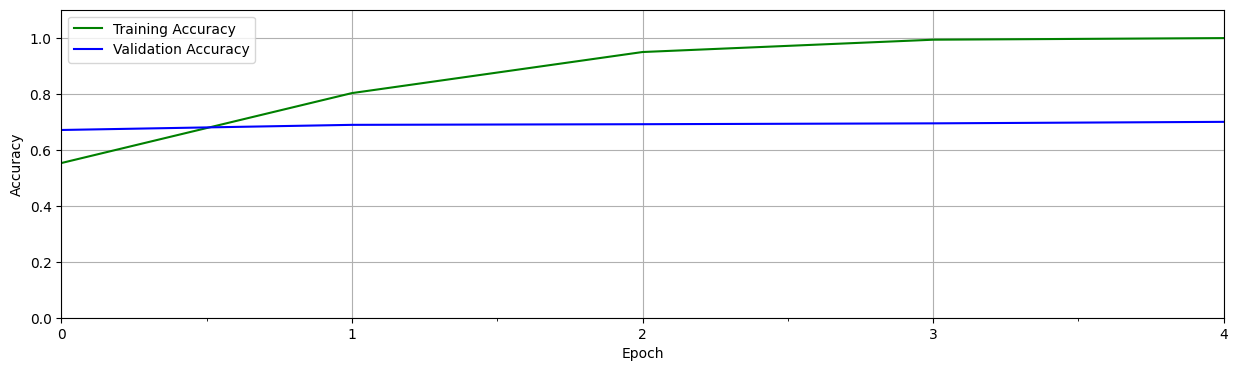

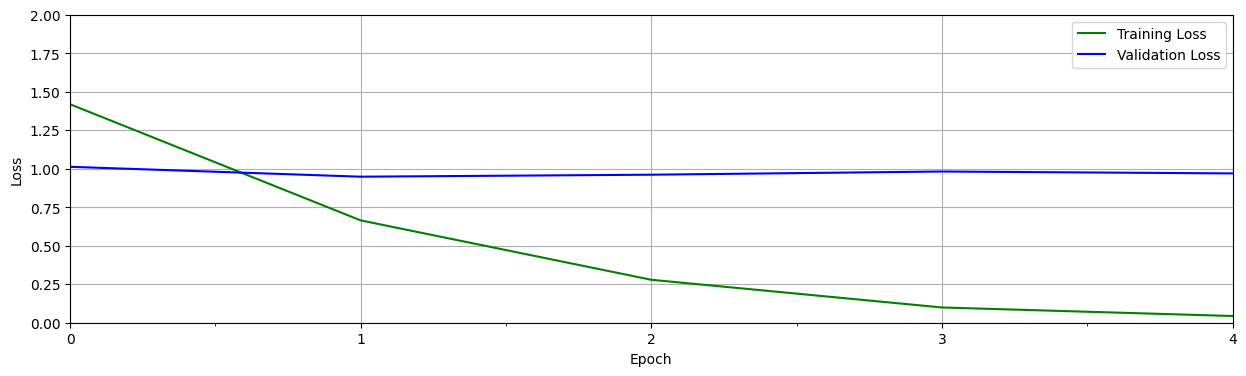

In [34]:
# Retrieve training results.
train_loss = history["train_loss"]
train_acc  = history["train_acc"]
valid_loss = history["valid_loss"]
valid_acc  = history["valid_acc"]


train_config = history["train_config"]

plot_results([ train_acc, valid_acc ],
            ylabel="Accuracy",
            ylim = [0.0, 1.1],
            metric_name=["Training Accuracy", "Validation Accuracy"],
            color=["g", "b"],
            training_config=TrainingConfig())

plot_results([ train_loss, valid_loss ],
            ylabel="Loss",
            ylim = [0.0, 2.0],
            metric_name=["Training Loss", "Validation Loss"],
            color=["g", "b"],
            training_config=TrainingConfig());

def prediction_batch(model: nn.Module, batch_inputs: torch.tensor):

    model.eval()

    with torch.no_grad():
        batch_ops = model(batch_inputs)

    batch_probs = batch_ops.softmax(dim=1)

    batch_confs, batch_cls_ids = batch_probs.max(dim=1)

    return torch.stack([batch_confs.cpu(), batch_cls_ids.cpu()], dim=1)

In [45]:
def prediction_batch(model: nn.Module, 
                     batch_inputs: torch.Tensor, 
                     device: torch.device):
    
    # Ensure model is in evaluation mode
    model.eval()

    # Move inputs to the correct device (CPU/CUDA)
    batch_inputs = batch_inputs.to(device)

    # Forward pass without tracking gradients
    with torch.no_grad():
        batch_ops = model(batch_inputs)

    # Calculate probabilities
    batch_probs = batch_ops.softmax(dim=1)

    # Extract max confidence values and their respective class IDs
    batch_confs, batch_cls_ids = batch_probs.max(dim=1)

    # Return them as separate tensors on the CPU
    return batch_confs.cpu(), batch_cls_ids.cpu()

In [46]:
# Setup containers
all_confs = []
all_preds = []
all_ids = []

# Loop through the unlabelled test data
for images, ids in test_loader:
    # Get predictions using your function
    confs, preds = prediction_batch(model, images, DEVICE)
    
    # Store results
    all_confs.extend(confs.numpy())
    all_preds.extend(preds.numpy())
    all_ids.extend(ids)

# Create a clean final dataframe
results_df = pd.DataFrame({
    'id': all_ids,
    'class_id': all_preds,
    'confidence': all_confs
})

In [49]:
# Grab the original class_to_idx mapping from your training dataset
class_to_idx = train_loader.dataset.class_to_idx

# Invert the dictionary: turns { 'ugali': 0 } into { 0: 'ugali' }
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

# Use pandas .map() to create the new column
results_df['class_name'] = results_df['class_id'].map(idx_to_class)

In [51]:
# Keep only the columns needed for submission
submission_df = results_df[['id', 'class_name']]

# Rename columns if the competition requires specific headers (e.g., 'label')
submission_df = submission_df.rename(columns={'class_name': 'class'})

# Save it to a CSV file
submission_df.to_csv('kenyan_food_submission.csv', index=False)

In [50]:
results_df

,id,class_id,confidence,class_name
0,9156739011499789258,12,0.223355,ugali
1,2049465964503133373,3,0.694496,kachumbari
2,6446998501027132988,9,0.934628,nyamachoma
3,4194396063119815321,12,0.804005,ugali
4,9018117998187006009,12,0.283618,ugali
...,...,...,...,...
1633,18302448610371772604,2,0.998810,githeri
1634,15920672464676076400,1,0.999134,chapati
1635,3232020170382870007,1,0.406299,chapati
1636,3094804487341098468,3,0.872959,kachumbari


## <font style="color:green">8. TensorBoard Log Link [5 Points]</font>

**Share your TensorBoard scalars logs link here You can also share (not mandatory) your GitHub link, if you have pushed this project in GitHub.**


Note: In light of the recent shutdown of tensorboard.dev, we have updated the submission requirements for your project. Instead of sharing a tensorboard.dev link, you are now required to upload your generated TensorBoard event files directly onto the lab. As an alternative, you may also include a screenshot of your TensorBoard output within your Jupyter notebook. This adjustment ensures that your data visualization and model training efforts are thoroughly documented and accessible for evaluation.

You are also welcome (and encouraged) to utilize alternative logging services like wandB or comet. In such instances, you can easily make your project logs publicly accessible and share the link with others.

## <font style="color:green">9. Kaggle Profile Link [50 Points]</font>

**Share your Kaggle profile link  with us here to score , points in  the competition.**

**For full points, you need a minimum accuracy of `75%` on the test data. If accuracy is less than `70%`, you gain  no points for this section.**


**Submit `submission.csv` (prediction for images in `test.csv`), in the `Submit Predictions` tab in Kaggle, to get evaluated for  this section.**